Here's a breakdown of the imported libraries and their common uses in data science and machine learning:

*   **`pandas as pd`**: A powerful open-source library for data manipulation and analysis. It provides data structures like DataFrames, which are essential for working with tabular data.
*   **`numpy as np`**: The fundamental package for numerical computing in Python. It provides support for arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays.
*   **`matplotlib.pyplot as plt`**: A comprehensive library for creating static, animated, and interactive visualizations in Python. `pyplot` is a collection of command-style functions that make Matplotlib work like MATLAB.
*   **`seaborn as sns`**: A data visualization library based on Matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.
*   **`%matplotlib inline`**: A magic command specific to Jupyter notebooks and IPython environments. It ensures that Matplotlib plots are displayed directly within the notebook output.
*   **`sklearn.preprocessing.OrdinalEncoder`**: Used for encoding categorical features as ordinal integers. This is suitable when categories have a natural order.
*   **`sklearn.preprocessing.OneHotEncoder`**: Used for encoding categorical features as one-hot numeric arrays. This is suitable when categories do not have a natural order and to avoid implying an ordinal relationship.
*   **`sklearn.impute.SimpleImputer`**: Used for handling missing values in datasets. It can replace missing values using strategies like mean, median, or most frequent.
*   **`sklearn.compose.make_column_transformer`**: A utility function to create a `ColumnTransformer` object, which applies different transformers to different columns of an array or DataFrame.
*   **`sklearn.pipeline.Pipeline`, `sklearn.pipeline.make_pipeline`**: Used to chain multiple processing steps (like preprocessing, imputation, and model training) into a single scikit-learn object. This helps in organizing and streamlining workflows.
*   **`sklearn.linear_model.LogisticRegression`**: Implements Logistic Regression, a linear model used for binary and multiclass classification.
*   **`sklearn.svm.SVC`**: Implements Support Vector Classifier, a powerful and versatile machine learning model capable of performing linear or non-linear classification, regression, and even outlier detection.
*   **`sklearn.tree.DecisionTreeClassifier`**: Implements Decision Tree Classifier, a non-parametric supervised learning method used for classification and regression.
*   **`sklearn.neighbors.KNeighborsClassifier`**: Implements K-Nearest Neighbors Classifier, a non-parametric method used for classification.
*   **`sklearn.naive_bayes.GaussianNB`**: Implements Gaussian Naive Bayes, a probabilistic classifier based on Bayes' theorem with strong (naive) independence assumptions between the features.
*   **`sklearn.model_selection.cross_val_score`**: Used for evaluating a score by cross-validation.
*   **`sklearn.model_selection.StratifiedKFold`**: Provides train/test indices to split data in train/test sets. This variation of K-fold cross-validation returns stratified folds, i.e., each set contains approximately the same percentage of samples of each target class.
*   **`sklearn.model_selection.train_test_split`**: Used to split arrays or matrices into random train and test subsets.
*   **`sklearn.model_selection.GridSearchCV`**: Used for exhaustively searching over specified parameter values for an estimator. It performs cross-validation to find the best combination of hyperparameters.

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, GridSearchCV

In [56]:
train_df=pd.read_csv('/content/sample_data/train.csv')
test_df=pd.read_csv('/content/sample_data/test.csv')


In [57]:
train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Age_Cut,Fare_cut,TITLE,Name_Length,Name_LengthGB,Name_size,TicketNumber,TicketNumberCounts,TicketLocation,Cabin_Assigned
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,...,"(20.125, 24.0]","(-0.001, 7.775]",Mr,23,"(20.0, 23.0]",NaN,21171,1,A/5,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,...,"(32.312, 38.0]","(52.369, 512.329]",Mrs,51,"(38.0, 82.0]",7.0,17599,1,PC,1
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,...,"(24.0, 28.0]","(7.775, 8.662]",Miss,22,"(20.0, 23.0]",2.0,3101282,1,STON/O2.,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,...,"(32.312, 38.0]","(52.369, 512.329]",Mrs,44,"(38.0, 82.0]",7.0,113803,2,Blank,1
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,...,"(32.312, 38.0]","(7.775, 8.662]",Mr,24,"(23.0, 25.0]",3.0,373450,1,Blank,0


In [58]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PassengerId         891 non-null    int64  
 1   Survived            891 non-null    int64  
 2   Pclass              891 non-null    int64  
 3   Name                891 non-null    object 
 4   Sex                 891 non-null    object 
 5   Age                 891 non-null    float64
 6   SibSp               891 non-null    int64  
 7   Parch               891 non-null    int64  
 8   Ticket              891 non-null    object 
 9   Fare                891 non-null    float64
 10  Cabin               891 non-null    object 
 11  Embarked            889 non-null    object 
 12  Family_Size         891 non-null    object 
 13  Age_Cut             714 non-null    object 
 14  Fare_cut            891 non-null    object 
 15  TITLE               891 non-null    object 
 16  Name_Len

In [59]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Name_Length,Name_size,TicketNumberCounts,Cabin_Assigned
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,852.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,3.462185,0.523008,0.381594,2.501684,26.965208,3.458920,1.794613,0.228956
std,257.353842,0.486592,0.836071,2.073232,1.102743,0.806057,1.722537,9.281607,2.389155,1.362175,0.420397
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,1.000000,0.000000
25%,223.500000,0.000000,2.000000,2.000000,0.000000,0.000000,1.000000,20.000000,1.000000,1.000000,0.000000
50%,446.000000,0.000000,3.000000,3.462185,0.000000,0.000000,3.000000,25.000000,4.000000,1.000000,0.000000
75%,668.500000,1.000000,3.000000,5.000000,1.000000,0.000000,4.000000,30.000000,6.000000,2.000000,0.000000
max,891.000000,1.000000,3.000000,7.000000,8.000000,6.000000,6.000000,82.000000,7.000000,7.000000,1.000000


In [60]:
train_df.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked,Family_Size,Age_Cut,Fare_cut,TITLE,Name_LengthGB,TicketNumber,TicketLocation
count,891,891,891,891,889,891,714,891,891,891,891,891
unique,891,2,681,9,3,4,8,6,9,8,679,33
top,"Dooley, Mr. Patrick",male,347082,U,S,Alone,"(0.419, 16.0]","(-0.001, 7.775]",Mr,"(11.999, 18.0]",1601,Blank
freq,1,577,7,687,644,537,100,156,517,140,7,665


In [61]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [62]:
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Age_Cut,Fare_cut,TITLE,Name_Length,Name_LengthGB,Name_size,TicketNumber,TicketNumberCounts,TicketLocation,Cabin_Assigned
886,887,0,2,"Montvila, Rev. Juozas",male,3.000000,0,0,211536,2.0,...,"(24.0, 28.0]","(8.662, 14.454]",Rev,21,"(20.0, 23.0]",2.0,211536,1,Blank,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,1.000000,0,0,112053,4.0,...,"(16.0, 20.125]","(26.0, 52.369]",Miss,28,"(27.25, 30.0]",5.0,112053,1,Blank,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,3.462185,1,2,W./C. 6607,3.0,...,NaN,"(14.454, 26.0]",Miss,40,"(38.0, 82.0]",7.0,6607,2,W/C,0
889,890,1,1,"Behr, Mr. Karl Howell",male,3.000000,0,0,111369,4.0,...,"(24.0, 28.0]","(26.0, 52.369]",Mr,21,"(20.0, 23.0]",2.0,111369,1,Blank,1
890,891,0,3,"Dooley, Mr. Patrick",male,4.000000,0,0,370376,0.0,...,"(28.0, 32.312]","(-0.001, 7.775]",Mr,19,"(18.0, 20.0]",1.0,370376,1,Blank,0


In [63]:
#Isse mujhe yeh pta chalega ki various classes me survival rate kya hoga
train_df.groupby(['Pclass'], as_index=False)['Survived'].mean()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [64]:
train_df.groupby(['Sex'], as_index=False)['Survived'].mean()
#74% female survival rate hai
#18% male survival rate hai

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [65]:
train_df.groupby(['SibSp'], as_index=False)['Survived'].mean()

,SibSp,Survived
0,0,0.345395
1,1,0.535885
2,2,0.464286
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [66]:
train_df.groupby(['Parch'], as_index=False)['Survived'].mean()

,Parch,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,3,0.600000
4,4,0.000000
5,5,0.200000
6,6,0.000000


In [67]:
#Kitni familes thi ship p jisme siblings spouse, parents and bacche or Jo plus 1 h voh Passenger k self k liye hai
train_df['Family_Size']= train_df['SibSp']+train_df['Parch']+1
test_df['Family_Size']= test_df['SibSp']+test_df['Parch']+1

In [68]:
train_df.groupby(['Family_Size'], as_index=False)['Survived'].mean()

,Family_Size,Survived
0,1,0.303538
1,2,0.552795
2,3,0.578431
3,4,0.724138
4,5,0.200000
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000


In [69]:
family_map= {1:'Alone', 2:'Small_Family', 3:'Small_Family', 4:'Small_Family', 5:'Medium_Family', 6:'Medium_Family', 7:'Large_Family', 8:'Large_Family', 11:"Large_Family"}
train_df['Family_Size']= train_df['Family_Size'].map(family_map)
test_df['Family_Size']= test_df['Family_Size'].map(family_map)

In [70]:
train_df.groupby(['Family_Size'], as_index=False)['Survived'].mean()

,Family_Size,Survived
0,Alone,0.303538
1,Large_Family,0.160000
2,Medium_Family,0.162162
3,Small_Family,0.578767


In [71]:
train_df.groupby(['Embarked'], as_index=False)['Survived'].mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


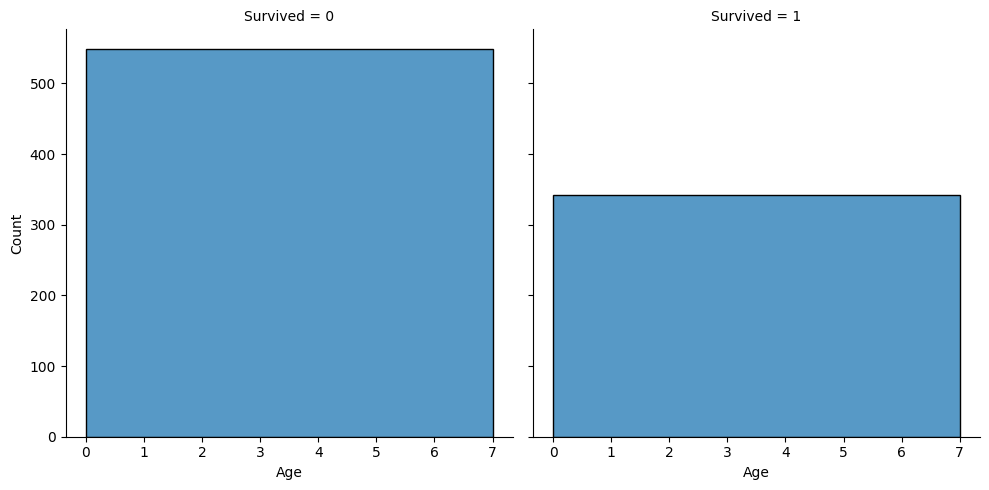

In [72]:
sns.displot(train_df, x='Age', col='Survived', binwidth=10, height=5)

In [73]:
train_df['Age_Cut']=pd.qcut(train_df['Age'],8)
test_df['Age_Cut']=pd.qcut(test_df['Age'],8)

In [74]:
train_df.groupby(['Age_Cut'], as_index=False)['Survived'].mean()

/tmp/ipykernel_1202/1587675067.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Age_Cut'], as_index=False)['Survived'].mean()


,Age_Cut,Survived
0,"(-0.001, 1.0]",0.458101
1,"(1.0, 2.0]",0.367347
2,"(2.0, 3.0]",0.352941
3,"(3.0, 3.462]",0.293785
4,"(3.462, 4.0]",0.416667
5,"(4.0, 5.0]",0.450549
6,"(5.0, 6.0]",0.329545
7,"(6.0, 7.0]",0.415730


In [75]:
train_df.loc[train_df['Age']<=16, 'Age']=0
train_df.loc[(train_df['Age']>16) & (train_df['Age']<=20.125),  'Age']=1
train_df.loc[(train_df['Age']>20.125) & (train_df['Age']<=24),  'Age']=2
train_df.loc[(train_df['Age']>24) & (train_df['Age']<=28),  'Age']=3
train_df.loc[(train_df['Age']>28) & (train_df['Age']<=32.312),  'Age']=4
train_df.loc[(train_df['Age']>32.312) & (train_df['Age']<=38),  'Age']=5
train_df.loc[(train_df['Age']>38) & (train_df['Age']<=47),  'Age']=6
train_df.loc[(train_df['Age']>47) & (train_df['Age']<=80),  'Age']=7
train_df.loc[train_df['Age'] > 80,  'Age']=8

test_df.loc[test_df['Age']<=16, 'Age']=0
test_df.loc[(test_df['Age']>16) & (test_df['Age']<=20.125),  'Age']=1
test_df.loc[(test_df['Age']>20.125) & (test_df['Age']<=24),  'Age']=2
test_df.loc[(test_df['Age']>24) & (test_df['Age']<=28),  'Age']=3
test_df.loc[(test_df['Age']>28) & (test_df['Age']<=32.312),  'Age']=4
test_df.loc[(test_df['Age']>32.312) & (test_df['Age']<=38),  'Age']=5
test_df.loc[(test_df['Age']>38) & (test_df['Age']<=47),  'Age']=6
test_df.loc[(test_df['Age']>47) & (test_df['Age']<=80),  'Age']=7
test_df.loc[test_df['Age'] > 80,  'Age']=8

In [76]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Age_Cut,Fare_cut,TITLE,Name_Length,Name_LengthGB,Name_size,TicketNumber,TicketNumberCounts,TicketLocation,Cabin_Assigned
0,1,0,3,"Braund, Mr. Owen Harris",male,0.0,1,0,A/5 21171,0.0,...,"(1.0, 2.0]","(-0.001, 7.775]",Mr,23,"(20.0, 23.0]",NaN,21171,1,A/5,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.0,1,0,PC 17599,5.0,...,"(4.0, 5.0]","(52.369, 512.329]",Mrs,51,"(38.0, 82.0]",7.0,17599,1,PC,1
2,3,1,3,"Heikkinen, Miss. Laina",female,0.0,0,0,STON/O2. 3101282,1.0,...,"(2.0, 3.0]","(7.775, 8.662]",Miss,22,"(20.0, 23.0]",2.0,3101282,1,STON/O2.,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.0,1,0,113803,5.0,...,"(4.0, 5.0]","(52.369, 512.329]",Mrs,44,"(38.0, 82.0]",7.0,113803,2,Blank,1
4,5,0,3,"Allen, Mr. William Henry",male,0.0,0,0,373450,1.0,...,"(4.0, 5.0]","(7.775, 8.662]",Mr,24,"(23.0, 25.0]",3.0,373450,1,Blank,0


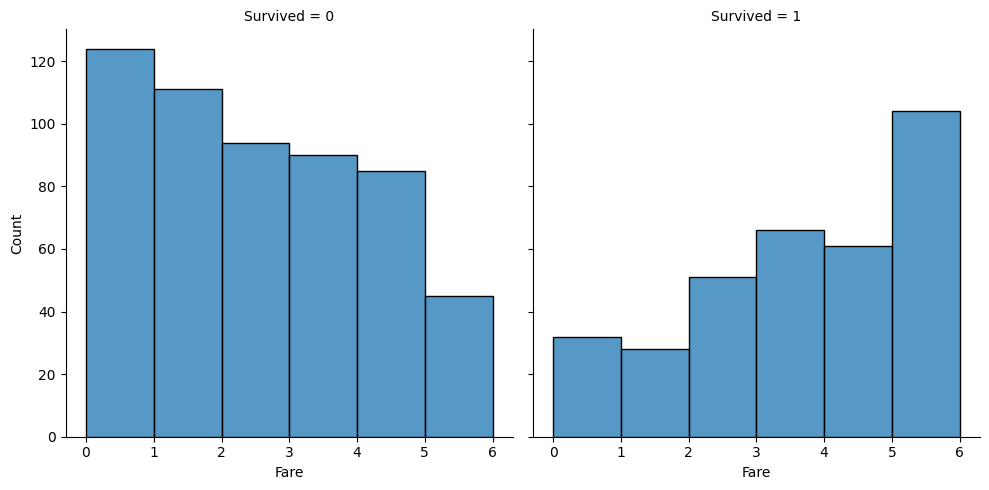

In [77]:
sns.displot(train_df, x='Fare', col='Survived', binwidth=1, height=5)

In [78]:
train_df['Fare_cut']=pd.qcut(train_df['Fare'],6, duplicates='drop')
test_df['Fare_Cut']=pd.qcut(test_df['Fare'],6, duplicates='drop')

In [79]:
train_df.groupby(['Fare_cut'], as_index=False)['Survived'].mean()

/tmp/ipykernel_1202/3412529244.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Fare_cut'], as_index=False)['Survived'].mean()


,Fare_cut,Survived
0,"(-0.001, 2.0]",0.252273
1,"(2.0, 3.0]",0.423077
2,"(3.0, 4.667]",0.417808
3,"(4.667, 6.0]",0.697987


In [80]:
train_df.loc[train_df['Fare']<=7.775, 'Fare']=0
train_df.loc[(train_df['Fare']>7.775) & (train_df['Fare']<=8.662),  'Fare']=1
train_df.loc[(train_df['Fare']>8.662) & (train_df['Fare']<=14.454),  'Fare']=2
train_df.loc[(train_df['Fare']>14.454) & (train_df['Fare']<=26),  'Fare']=3
train_df.loc[(train_df['Fare']>26) & (train_df['Fare']<=52.369),  'Fare']=4
train_df.loc[(train_df['Fare']>52.329) & (train_df['Fare']<=512.329),  'Fare']=5
train_df.loc[train_df['Fare']>512.329,  'Fare']=6

test_df.loc[test_df['Fare']<=7.775, 'Fare']=0
test_df.loc[(test_df['Fare']>7.775) & (test_df['Fare']<=8.662),  'Fare']=1
test_df.loc[(test_df['Fare']>20.125) & (test_df['Fare']<=14),  'Fare']=2
test_df.loc[(test_df['Fare']>24) & (test_df['Fare']<=26),  'Fare']=3
test_df.loc[(test_df['Fare']>28) & (test_df['Fare']<=53.369),  'Fare']=4
test_df.loc[(test_df['Fare']>32.312) & (test_df['Fare']<=512.329),  'Fare']=5
test_df.loc[(test_df['Fare']>38) & (test_df['Fare']<=47),  'Fare']=6


In [81]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Age_Cut,Fare_cut,TITLE,Name_Length,Name_LengthGB,Name_size,TicketNumber,TicketNumberCounts,TicketLocation,Cabin_Assigned
0,1,0,3,"Braund, Mr. Owen Harris",male,0.0,1,0,A/5 21171,0.0,...,"(1.0, 2.0]","(-0.001, 2.0]",Mr,23,"(20.0, 23.0]",NaN,21171,1,A/5,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.0,1,0,PC 17599,0.0,...,"(4.0, 5.0]","(4.667, 6.0]",Mrs,51,"(38.0, 82.0]",7.0,17599,1,PC,1
2,3,1,3,"Heikkinen, Miss. Laina",female,0.0,0,0,STON/O2. 3101282,0.0,...,"(2.0, 3.0]","(-0.001, 2.0]",Miss,22,"(20.0, 23.0]",2.0,3101282,1,STON/O2.,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.0,1,0,113803,0.0,...,"(4.0, 5.0]","(4.667, 6.0]",Mrs,44,"(38.0, 82.0]",7.0,113803,2,Blank,1
4,5,0,3,"Allen, Mr. William Henry",male,0.0,0,0,373450,0.0,...,"(4.0, 5.0]","(-0.001, 2.0]",Mr,24,"(23.0, 25.0]",3.0,373450,1,Blank,0


In [82]:
train_df['TITLE']= train_df['Name'].str.split(pat=",",expand=True)[1].str.split(pat=".",expand=True)[0].apply(lambda x: x.strip())
test_df['TITLE']= test_df['Name'].str.split(pat=",",expand=True)[1].str.split(pat=".",expand=True)[0].apply(lambda x: x.strip())

In [83]:
train_df.groupby(['TITLE'], as_index=False)['Survived'].mean()
#Military-Capt, Col, Major
#noble- Jonkheer, the Countess, Don, Lady. Sir
#unmaried Female- Mlle, Ms, Mme

,TITLE,Survived
0,Capt,0.000000
1,Col,0.500000
2,Don,0.000000
3,Dr,0.428571
4,Jonkheer,0.000000
5,Lady,1.000000
6,Major,0.500000
7,Master,0.575000
8,Miss,0.697802
9,Mlle,1.000000


In [84]:
train_df['TITLE']=train_df['TITLE'].replace({
    'Capt':'Military',
    'Col':'Military',
    'Major':'Military',
    'Jonkheer':'Noble',
    "the Countess":'Noble',
    'Don':"Noble",
    "Sir":"Noble",
    "Lady":"Noble",
    "Mlle":"Unmarried_Female",
    "Ms":"Unmarried_Female",
    "Mme":"Unmarried_Female"
})
test_df['TITLE']=test_df['TITLE'].replace({
    'Capt':'Military',
    'Col':'Military',
    'Major':'Military',
    'Jonkheer':'Noble',
    "the Countess":'Noble',
    'Don':"Noble",
    "Sir":"Noble",
    "Lady":"Noble",
    "Mlle":"Unmarried_Female",
    "Ms":"Unmarried_Female",
    "Mme":"Unmarried_Female"
})

In [85]:
train_df.groupby(['TITLE'], as_index=False)['Survived'].agg(['count', 'mean'])

,TITLE,count,mean
0,Dr,7,0.428571
1,Master,40,0.575000
2,Military,5,0.400000
3,Miss,182,0.697802
4,Mr,517,0.156673
5,Mrs,125,0.792000
6,Noble,5,0.600000
7,Rev,6,0.000000
8,Unmarried_Female,4,1.000000


In [86]:
train_df['Name_Length']= train_df['Name'].apply(lambda x: len(x))
test_df['Name_Length']= test_df['Name'].apply(lambda x: len(x))

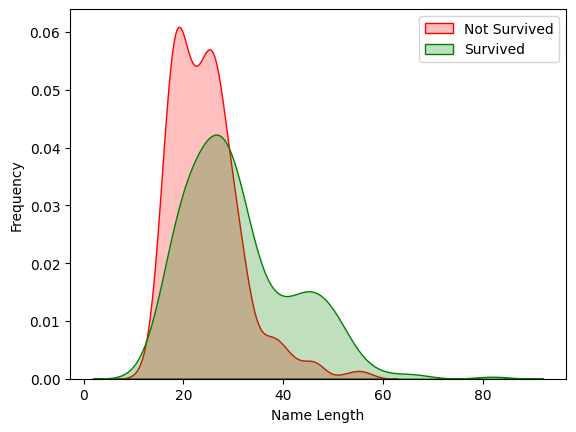

In [87]:
g=sns.kdeplot(train_df['Name_Length'][(train_df['Survived']==0) & (train_df['Name_Length'].notnull())], color='Red', fill=True)
g=sns.kdeplot(train_df['Name_Length'][(train_df['Survived']==1) & (train_df['Name_Length'].notnull())],ax=g, color='Green', fill=True)
g.set_xlabel('Name Length')
g.set_ylabel('Frequency')
g=g.legend(['Not Survived', 'Survived'])

In [88]:
train_df['Name_LengthGB']=pd.qcut(train_df['Name_Length'],8)
test_df['Name_LengthGB']=pd.qcut(test_df['Name_Length'],8)

In [89]:
train_df.groupby(['Name_LengthGB'], as_index=False)['Survived'].mean()

/tmp/ipykernel_1202/554738133.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Name_LengthGB'], as_index=False)['Survived'].mean()


,Name_LengthGB,Survived
0,"(11.999, 18.0]",0.214286
1,"(18.0, 20.0]",0.252427
2,"(20.0, 23.0]",0.307692
3,"(23.0, 25.0]",0.346939
4,"(25.0, 27.25]",0.292929
5,"(27.25, 30.0]",0.428571
6,"(30.0, 38.0]",0.517241
7,"(38.0, 82.0]",0.745283


In [90]:
train_df.loc[train_df['Name_Length'] <= 18, 'Name_size'] = 0
train_df.loc[(train_df['Name_Length'] > 18) & (train_df['Name_Length'] <= 20), 'Name_size'] = 1
train_df.loc[(train_df['Name_Length'] > 20) & (train_df['Name_Length'] <= 22), 'Name_size'] = 2
train_df.loc[(train_df['Name_Length'] > 23) & (train_df['Name_Length'] <= 25), 'Name_size'] = 3
train_df.loc[(train_df['Name_Length'] > 25) & (train_df['Name_Length'] <= 28), 'Name_size'] = 4
train_df.loc[(train_df['Name_Length'] > 27.25) & (train_df['Name_Length'] <= 33), 'Name_size'] = 5
train_df.loc[(train_df['Name_Length'] > 30) & (train_df['Name_Length'] <= 82), 'Name_size'] = 6
train_df.loc[(train_df['Name_Length'] > 38) & (train_df['Name_Length'] <= 82), 'Name_size'] = 7
train_df.loc[train_df['Name_Length'] > 82, 'Name_size'] = 8

test_df.loc[test_df['Name_Length'] <= 18, 'Name_size'] = 0
test_df.loc[(test_df['Name_Length'] > 18) & (test_df['Name_Length'] <= 20), 'Name_size'] = 1
test_df.loc[(test_df['Name_Length'] > 20) & (test_df['Name_Length'] <= 22), 'Name_size'] = 2
test_df.loc[(test_df['Name_Length'] > 23) & (test_df['Name_Length'] <= 25), 'Name_size'] = 3
test_df.loc[(test_df['Name_Length'] > 25) & (test_df['Name_Length'] <= 28), 'Name_size'] = 4
test_df.loc[(test_df['Name_Length'] > 27.25) & (test_df['Name_Length'] <= 33), 'Name_size'] = 5
test_df.loc[(test_df['Name_Length'] > 30) & (test_df['Name_Length'] <= 82), 'Name_size'] = 6
test_df.loc[(test_df['Name_Length'] > 38) & (test_df['Name_Length'] <= 82), 'Name_size'] = 7
test_df.loc[test_df['Name_Length'] > 82, 'Name_size'] = 8

In [91]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Age_Cut,Fare_cut,TITLE,Name_Length,Name_LengthGB,Name_size,TicketNumber,TicketNumberCounts,TicketLocation,Cabin_Assigned
0,1,0,3,"Braund, Mr. Owen Harris",male,0.0,1,0,A/5 21171,0.0,...,"(1.0, 2.0]","(-0.001, 2.0]",Mr,23,"(20.0, 23.0]",NaN,21171,1,A/5,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.0,1,0,PC 17599,0.0,...,"(4.0, 5.0]","(4.667, 6.0]",Mrs,51,"(38.0, 82.0]",7.0,17599,1,PC,1
2,3,1,3,"Heikkinen, Miss. Laina",female,0.0,0,0,STON/O2. 3101282,0.0,...,"(2.0, 3.0]","(-0.001, 2.0]",Miss,22,"(20.0, 23.0]",2.0,3101282,1,STON/O2.,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.0,1,0,113803,0.0,...,"(4.0, 5.0]","(4.667, 6.0]",Mrs,44,"(38.0, 82.0]",7.0,113803,2,Blank,1
4,5,0,3,"Allen, Mr. William Henry",male,0.0,0,0,373450,0.0,...,"(4.0, 5.0]","(-0.001, 2.0]",Mr,24,"(23.0, 25.0]",3.0,373450,1,Blank,0


In [92]:
train_df['Ticket']

,Ticket
0,A/5 21171
1,PC 17599
2,STON/O2. 3101282
3,113803
4,373450
...,...
886,211536
887,112053
888,W./C. 6607
889,111369


In [93]:
train_df['TicketNumber']= train_df['Ticket'].apply(lambda x: pd.Series({'Ticket':x.split()[-1]}))
test_df['TicketNumber']= test_df['Ticket'].apply(lambda x: pd.Series({'Ticket':x.split()[-1]}))

In [94]:
train_df.groupby(['TicketNumber'], as_index=False)['Survived'].agg(['count', 'mean']).sort_values('count',ascending=False)

,TicketNumber,count,mean
94,1601,7,0.714286
196,2343,7,0.000000
464,347082,7,0.000000
468,347088,6,0.000000
358,3101295,6,0.000000
...,...,...,...
276,2667,1,1.000000
278,2669,1,0.000000
279,26707,1,0.000000
280,2671,1,0.000000


In [95]:
train_df.groupby('TicketNumber')['TicketNumber'].transform('count')

,TicketNumber
0,1
1,1
2,1
3,2
4,1
...,...
886,1
887,1
888,2
889,1


In [96]:
train_df['TicketNumberCounts']= train_df.groupby('TicketNumber')['TicketNumber'].transform('count')
test_df['TicketNumberCounts']= test_df.groupby('TicketNumber')['TicketNumber'].transform('count')

In [97]:
train_df.groupby(['TicketNumberCounts'], as_index=False)['Survived'].agg(['count', 'mean']).sort_values('count',ascending=False)

,TicketNumberCounts,count,mean
0,1,544,0.295956
1,2,188,0.569149
2,3,66,0.712121
3,4,44,0.500000
6,7,21,0.238095
5,6,18,0.000000
4,5,10,0.000000


In [98]:
train_df['Ticket'].str.split(pat=" ", expand=True)

,0,1,2
0,A/5,21171,None
1,PC,17599,None
2,STON/O2.,3101282,None
3,113803,None,None
4,373450,None,None
...,...,...,...
886,211536,None,None
887,112053,None,None
888,W./C.,6607,None
889,111369,None,None


In [99]:
train_df['TicketLocation']=np.where(train_df['Ticket'].str.split(pat=" ",expand=True)[1].notna(), train_df['Ticket'].str.split(pat=" ", expand=True)[0].apply(lambda x:x.strip()), 'Blank')
test_df['TicketLocation']=np.where(test_df['Ticket'].str.split(pat=" ",expand=True)[1].notna(), test_df['Ticket'].str.split(pat=" ", expand=True)[0].apply(lambda x:x.strip()), 'Blank')

In [100]:
train_df['TicketLocation'].value_counts()

,count
TicketLocation,
Blank,665
PC,60
C.A.,27
STON/O,12
A/5,10
W./C.,9
CA.,8
SOTON/O.Q.,8
A/5.,7


In [101]:
train_df['TicketLocation']= train_df['TicketLocation'].replace({ 'SOTON/O.Q.':'SOTON/OQ',
    'C.A.':'CA',
    'CA.':'CA',
    'SC/PARIS':'SC/Paris',
    'S.C./PARIS':'SC/Paris',
    'A/4.':'A/4',
    'A/5.':'A/5',
    'A.5.':'A/5',
    'A./5.':'A/5',
    'W./C.':'W/C',
})

test_df['TicketLocation']= test_df['TicketLocation'].replace({ 'SOTON/O.Q.':'SOTON/OQ',
    'C.A.':'CA',
    'CA.':'CA',
    'SC/PARIS':'SC/Paris',
    'S.C./PARIS':'SC/Paris',
    'A/4.':'A/4',
    'A/5.':'A/5',
    'A.5.':'A/5',
    'A./5.':'A/5',
    'W./C.':'W/C',
})

In [102]:
train_df.groupby(['TicketLocation'], as_index=False)['Survived'].agg(['count', 'mean'])

,TicketLocation,count,mean
0,A/4,6,0.000000
1,A/5,21,0.095238
2,A/S,1,0.000000
3,A4.,1,0.000000
4,Blank,665,0.383459
5,C,5,0.400000
6,C.A./SOTON,1,0.000000
7,CA,41,0.341463
8,F.C.,1,0.000000
9,F.C.C.,5,0.800000


In [103]:
train_df['Cabin']=train_df['Cabin'].fillna('U')
train_df['Cabin']=pd.Series([i[0] if not pd.isnull(i) else 'x' for i in train_df['Cabin']])

test_df['Cabin']=train_df['Cabin'].fillna('U')
test_df['Cabin']=pd.Series([i[0] if not pd.isnull(i) else 'x' for i in train_df['Cabin']])

In [104]:
train_df.groupby(['Cabin'], as_index=False)['Survived'].agg(['count', 'mean'])

,Cabin,count,mean
0,A,15,0.466667
1,B,47,0.744681
2,C,59,0.593220
3,D,33,0.757576
4,E,32,0.750000
5,F,13,0.615385
6,G,4,0.500000
7,T,1,0.000000
8,U,687,0.299854


In [105]:
train_df['Cabin_Assigned']= train_df["Cabin"].apply(lambda x: 0 if x in ['U'] else 1)
test_df['Cabin_Assigned']= test_df["Cabin"].apply(lambda x: 0 if x in ['U'] else 1)

In [106]:
train_df.groupby(['Cabin_Assigned'], as_index=False)['Survived'].agg(['count', 'mean'])

,Cabin_Assigned,count,mean
0,0,687,0.299854
1,1,204,0.666667


In [107]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Age_Cut,Fare_cut,TITLE,Name_Length,Name_LengthGB,Name_size,TicketNumber,TicketNumberCounts,TicketLocation,Cabin_Assigned
0,1,0,3,"Braund, Mr. Owen Harris",male,0.0,1,0,A/5 21171,0.0,...,"(1.0, 2.0]","(-0.001, 2.0]",Mr,23,"(20.0, 23.0]",NaN,21171,1,A/5,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.0,1,0,PC 17599,0.0,...,"(4.0, 5.0]","(4.667, 6.0]",Mrs,51,"(38.0, 82.0]",7.0,17599,1,PC,1
2,3,1,3,"Heikkinen, Miss. Laina",female,0.0,0,0,STON/O2. 3101282,0.0,...,"(2.0, 3.0]","(-0.001, 2.0]",Miss,22,"(20.0, 23.0]",2.0,3101282,1,STON/O2.,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.0,1,0,113803,0.0,...,"(4.0, 5.0]","(4.667, 6.0]",Mrs,44,"(38.0, 82.0]",7.0,113803,2,Blank,1
4,5,0,3,"Allen, Mr. William Henry",male,0.0,0,0,373450,0.0,...,"(4.0, 5.0]","(-0.001, 2.0]",Mr,24,"(23.0, 25.0]",3.0,373450,1,Blank,0


In [108]:
train_df.shape

(891, 23)

In [109]:
test_df.shape

(418, 22)

In [110]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   PassengerId         891 non-null    int64   
 1   Survived            891 non-null    int64   
 2   Pclass              891 non-null    int64   
 3   Name                891 non-null    object  
 4   Sex                 891 non-null    object  
 5   Age                 891 non-null    float64 
 6   SibSp               891 non-null    int64   
 7   Parch               891 non-null    int64   
 8   Ticket              891 non-null    object  
 9   Fare                891 non-null    float64 
 10  Cabin               891 non-null    object  
 11  Embarked            889 non-null    object  
 12  Family_Size         891 non-null    object  
 13  Age_Cut             891 non-null    category
 14  Fare_cut            891 non-null    category
 15  TITLE               891 non-null    obje

In [111]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family_Size',
       'Age_Cut', 'Fare_cut', 'TITLE', 'Name_Length', 'Name_LengthGB',
       'Name_size', 'TicketNumber', 'TicketNumberCounts', 'TicketLocation',
       'Cabin_Assigned'],
      dtype='object')

In [112]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   PassengerId         418 non-null    int64   
 1   Pclass              418 non-null    int64   
 2   Name                418 non-null    object  
 3   Sex                 418 non-null    object  
 4   Age                 418 non-null    float64 
 5   SibSp               418 non-null    int64   
 6   Parch               418 non-null    int64   
 7   Ticket              418 non-null    object  
 8   Fare                418 non-null    float64 
 9   Cabin               418 non-null    object  
 10  Embarked            418 non-null    object  
 11  Family_Size         418 non-null    object  
 12  Age_Cut             418 non-null    category
 13  Fare_Cut            418 non-null    category
 14  TITLE               418 non-null    object  
 15  Name_Length         418 non-null    int6

In [113]:
train_df['Age']=train_df['Age'].fillna(train_df['Age'].mean())
test_df['Age']=test_df['Age'].fillna(test_df['Age'].mean())
test_df['Fare']=test_df['Fare'].fillna(test_df['Fare'].mean())

In [114]:
train_df.to_csv('/content/sample_data/train.csv', index=False)
test_df.to_csv('/content/sample_data/test.csv', index=False)
print('Preprocessed train_df and test_df saved to CSV files.')

Preprocessed train_df and test_df saved to CSV files.


In [115]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Age_Cut,Fare_cut,TITLE,Name_Length,Name_LengthGB,Name_size,TicketNumber,TicketNumberCounts,TicketLocation,Cabin_Assigned
0,1,0,3,"Braund, Mr. Owen Harris",male,0.0,1,0,A/5 21171,0.0,...,"(1.0, 2.0]","(-0.001, 2.0]",Mr,23,"(20.0, 23.0]",NaN,21171,1,A/5,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.0,1,0,PC 17599,0.0,...,"(4.0, 5.0]","(4.667, 6.0]",Mrs,51,"(38.0, 82.0]",7.0,17599,1,PC,1
2,3,1,3,"Heikkinen, Miss. Laina",female,0.0,0,0,STON/O2. 3101282,0.0,...,"(2.0, 3.0]","(-0.001, 2.0]",Miss,22,"(20.0, 23.0]",2.0,3101282,1,STON/O2.,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.0,1,0,113803,0.0,...,"(4.0, 5.0]","(4.667, 6.0]",Mrs,44,"(38.0, 82.0]",7.0,113803,2,Blank,1
4,5,0,3,"Allen, Mr. William Henry",male,0.0,0,0,373450,0.0,...,"(4.0, 5.0]","(-0.001, 2.0]",Mr,24,"(23.0, 25.0]",3.0,373450,1,Blank,0


# **Pipeline**

In [116]:
ohe= OneHotEncoder(sparse_output=False)#Converts categorical text data (like "Red", "Blue", "Green") into binary columns of 0s and 1s.
ode=OrdinalEncoder#Converts categorical text data into ordered integer values (like "Low" = 0, "Medium" = 1, "High" = 2).
SI= SimpleImputer(strategy='most_frequent')#Fills in missing values (such as NaN or None) in a dataset. By specifying strategy='most_frequent', it replaces any missing value in a column with the mode (the most frequently occurring value), which is particularly useful for handling missing data in categorical columns

In [117]:
ode_cols=['Family_Size_Grouped']
ohe_cols=['Sex','Embarked']

In [118]:
X= train_df.drop(['Survived'], axis=1)
y=train_df['Survived']
X_test= test_df.drop(['Age_Cut', 'Fare_Cut'], axis=1)

In [119]:
X_train, X_valid, y_train, y_valid= train_test_split(X, y, test_size=0.2,stratify=y, random_state=21)

In [120]:
ordinal_pipeline= Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('one-hot',OneHotEncoder(handle_unknown= 'ignore', sparse_output=False))
])

In [121]:
ohe_pipeline=Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('one-hot', OneHotEncoder(handle_unknown= 'ignore', sparse_output=False))
])

In [169]:
numerical_features = ['Pclass', 'Age', 'Fare', 'Name_Length', 'Name_size', 'TicketNumberCounts', 'Cabin_Assigned']
categorical_features = ['Sex', 'Embarked', 'Family_Size', 'TITLE', 'TicketLocation', 'Cabin']

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Add an imputer for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')) # Using mean for numerical imputation
])

col_trans = ColumnTransformer(
    transformers=[
        ('num_features', numerical_transformer, numerical_features), # Apply numerical transformer
        ('cat_features', categorical_transformer, categorical_features)
    ],
    remainder='drop',
    n_jobs=-1
)

# **HyperParameter Tuning**

RANDOM FOREST CLASSIFIER

In [151]:
rfc= RandomForestClassifier()

In [152]:
param_grid_rfc ={
    'randomforestclassifier__n_estimators': [100, 150, 200],
    'randomforestclassifier__min_samples_split': [5, 10, 15],
    'randomforestclassifier__max_depth': [8,9,10,15,20],
    "randomforestclassifier__min_samples_leaf":[1,2,4],
    'randomforestclassifier__criterion': ['gini', 'entropy'],
}

In [154]:
pipeline_rfc = make_pipeline(col_trans, rfc)
CV_rfc= GridSearchCV(estimator=pipeline_rfc, param_grid=param_grid_rfc, cv=StratifiedKFold(n_splits=5), n_jobs=-1, verbose=2)
CV_rfc.fit(X_train, y_train)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(n_jobs=-1,
                                                          transformers=[('num_features',
                                                                         'passthrough',
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'Fare',
                                                                          'Name_Length',
                                                                          'Name_size',
                                                                          'TicketNumberCounts',
                                                                          'Cabin_Assigned']),
                                                                        ('cat_features',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy=...
                                       ('randomforestclassifier',
                                        RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__criterion': ['gini',
                                                               'entropy'],
                         'randomforestclassifier__max_depth': [8, 9, 10, 15,
                                                               20],
                         'randomforestclassifier__min_samples_leaf': [1, 2, 4],
                         'randomforestclassifier__min_samples_split': [5, 10,
                                                                       15],
                         'randomforestclassifier__n_estimators': [100, 150,
                                                                  200]},
             verbose=2)

In [158]:
pipefinalrfc = CV_rfc.best_estimator_

In [159]:
print(CV_rfc.best_params_)
print(CV_rfc.best_score_)

{'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 8, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 150}
0.8384812370727864


DECISION TREE CLASSIFIER

In [155]:
dtc= DecisionTreeClassifier()

In [156]:
param_grid_dtc ={
    'decisiontreeclassifier__min_samples_split': [5, 10, 15],
    'decisiontreeclassifier__max_depth': [10, 20, 30],
    "decisiontreeclassifier__min_samples_leaf":[1,2,4],
    'decisiontreeclassifier__criterion': ['gini', 'entropy'],
}

In [157]:
pipeline_dtc = make_pipeline(col_trans, dtc)
CV_dtc= GridSearchCV(estimator=pipeline_dtc, param_grid=param_grid_dtc, cv=StratifiedKFold(n_splits=5), n_jobs=-1, verbose=2)
CV_dtc.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(n_jobs=-1,
                                                          transformers=[('num_features',
                                                                         'passthrough',
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'Fare',
                                                                          'Name_Length',
                                                                          'Name_size',
                                                                          'TicketNumberCounts',
                                                                          'Cabin_Assigned']),
                                                                        ('cat_features',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy=...
                                                                          'Embarked',
                                                                          'Family_Size',
                                                                          'TITLE',
                                                                          'TicketLocation',
                                                                          'Cabin'])])),
                                       ('decisiontreeclassifier',
                                        DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'decisiontreeclassifier__criterion': ['gini',
                                                               'entropy'],
                         'decisiontreeclassifier__max_depth': [10, 20, 30],
                         'decisiontreeclassifier__min_samples_leaf': [1, 2, 4],
                         'decisiontreeclassifier__min_samples_split': [5, 10,
                                                                       15]},
             verbose=2)

In [160]:
pipefinaldtc = CV_dtc.best_estimator_

In [161]:
print(CV_dtc.best_params_)
print(CV_dtc.best_score_)

{'decisiontreeclassifier__criterion': 'entropy', 'decisiontreeclassifier__max_depth': 20, 'decisiontreeclassifier__min_samples_leaf': 4, 'decisiontreeclassifier__min_samples_split': 5}
0.8244459765586527


K-NEIGHBOURS CLASSIFIER

In [162]:
knn= KNeighborsClassifier()

In [163]:
param_grid_knn ={
   'kneighborsclassifier__n_neighbors': [3,5,7,9,11],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'kneighborsclassifier__p': [1,2],
}

In [170]:
pipeline_knn = make_pipeline(col_trans, knn)
CV_knn= GridSearchCV(estimator=pipeline_knn, param_grid=param_grid_knn, cv=StratifiedKFold(n_splits=5), n_jobs=-1, verbose=2)
CV_knn.fit(X_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(n_jobs=-1,
                                                          transformers=[('num_features',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'Fare',
                                                                          'Name_Length',
                                                                          'Name_size',
                                                                          'TicketNumberCounts',
                                                                          'Cabin_Assigned']),
                                                                        ('cat_features',
                                                                         Pipeline(steps=[('...
                                                                          'Embarked',
                                                                          'Family_Size',
                                                                          'TITLE',
                                                                          'TicketLocation',
                                                                          'Cabin'])])),
                                       ('kneighborsclassifier',
                                        KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'kneighborsclassifier__algorithm': ['auto',
                                                             'ball_tree',
                                                             'kd_tree',
                                                             'brute'],
                         'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11],
                         'kneighborsclassifier__p': [1, 2],
                         'kneighborsclassifier__weights': ['uniform',
                                                           'distance']},
             verbose=2)

In [173]:
pipefinalknn = CV_knn.best_estimator_

In [174]:
print(CV_knn.best_params_)
print(CV_knn.best_score_)

{'kneighborsclassifier__algorithm': 'auto', 'kneighborsclassifier__n_neighbors': 3, 'kneighborsclassifier__p': 1, 'kneighborsclassifier__weights': 'uniform'}
0.8019994090416626


SUPPORT VECTOR CLASSIFIER

In [166]:
svc=  SVC()

In [167]:
param_grid_svc ={
   'svc__C': [110,10,1.0,0.1,0.001,0.001],
   'svc__kernel' : ['linear', 'poly', 'rbf', 'sigmoid'],
   'svc__gamma' : ['scale', 'auto']
}

In [171]:
pipeline_svc = make_pipeline(col_trans, svc)
CV_svc= GridSearchCV(estimator=pipeline_svc, param_grid=param_grid_svc, cv=StratifiedKFold(n_splits=5), n_jobs=-1, verbose=2)
CV_svc.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(n_jobs=-1,
                                                          transformers=[('num_features',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'Fare',
                                                                          'Name_Length',
                                                                          'Name_size',
                                                                          'TicketNumberCounts',
                                                                          'Cabin_Assigned']),
                                                                        ('cat_features',
                                                                         Pipeline(steps=[('...',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['Sex',
                                                                          'Embarked',
                                                                          'Family_Size',
                                                                          'TITLE',
                                                                          'TicketLocation',
                                                                          'Cabin'])])),
                                       ('svc', SVC())]),
             n_jobs=-1,
             param_grid={'svc__C': [110, 10, 1.0, 0.1, 0.001, 0.001],
                         'svc__gamma': ['scale', 'auto'],
                         'svc__kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             verbose=2)

In [175]:
pipefinalsvc = CV_svc.best_estimator_

In [176]:
print(CV_svc.best_params_)
print(CV_svc.best_score_)

{'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
0.8328769821727569


In [172]:
lr= LogisticRegression()

In [177]:
param_grid_lr ={
   'logisticregression__C': [110,10,1.0,0.1,0.001,0.001],
}

In [178]:
pipeline_lr = make_pipeline(col_trans, lr)
CV_lr= GridSearchCV(estimator=pipeline_lr, param_grid=param_grid_lr, cv=StratifiedKFold(n_splits=5), n_jobs=-1, verbose=2)
CV_lr.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(n_jobs=-1,
                                                          transformers=[('num_features',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'Fare',
                                                                          'Name_Length',
                                                                          'Name_size',
                                                                          'TicketNumberCounts',
                                                                          'Cabin_Assigned']),
                                                                        ('cat_features',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['Sex',
                                                                          'Embarked',
                                                                          'Family_Size',
                                                                          'TITLE',
                                                                          'TicketLocation',
                                                                          'Cabin'])])),
                                       ('logisticregression',
                                        LogisticRegression())]),
             n_jobs=-1,
             param_grid={'logisticregression__C': [110, 10, 1.0, 0.1, 0.001,
                                                   0.001]},
             verbose=2)

In [179]:
pipefinallr = CV_lr.best_estimator_

In [180]:
print(CV_lr.best_params_)
print(CV_lr.best_score_)

{'logisticregression__C': 1.0}
0.8146360681571949


In [181]:
gnb= GaussianNB()

In [182]:
param_grid_gnb ={
   'gaussiannb__var_smoothing': [0.00000001, 0.000000001, 0.00000001],
}

In [183]:
pipeline_gnb = make_pipeline(col_trans, gnb)
CV_gnb= GridSearchCV(estimator=pipeline_gnb, param_grid=param_grid_gnb, cv=StratifiedKFold(n_splits=5), n_jobs=-1, verbose=2)
CV_gnb.fit(X_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(n_jobs=-1,
                                                          transformers=[('num_features',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'Fare',
                                                                          'Name_Length',
                                                                          'Name_size',
                                                                          'TicketNumberCounts',
                                                                          'Cabin_Assigned']),
                                                                        ('cat_features',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['Sex',
                                                                          'Embarked',
                                                                          'Family_Size',
                                                                          'TITLE',
                                                                          'TicketLocation',
                                                                          'Cabin'])])),
                                       ('gaussiannb', GaussianNB())]),
             n_jobs=-1,
             param_grid={'gaussiannb__var_smoothing': [1e-08, 1e-09, 1e-08]},
             verbose=2)

In [184]:
pipefinalgnb = CV_gnb.best_estimator_

In [186]:
print(CV_gnb.best_params_)
print(CV_gnb.best_score_)

{'gaussiannb__var_smoothing': 1e-08}
0.45917462818871274


In [188]:
Y_pred= pipefinalrfc.predict(X_test)
Y_pred2= pipefinaldtc.predict(X_test)
Y_pred3= pipefinalsvc.predict(X_test)
Y_pred4= pipefinallr.predict(X_test)
Y_pred5= pipefinalgnb.predict(X_test)
Y_pred6= pipefinalknn.predict(X_test)

In [189]:
submission = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": Y_pred
    })

submission2 = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": Y_pred2
    })

submission3 = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": Y_pred3
    })

submission4 = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": Y_pred4
    })

submission5 = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": Y_pred5
    })

submission6 = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": Y_pred6
    })



In [195]:
submission.to_csv('/content/sample_data/submission.csv', index=False)

In [196]:
submission2.to_csv('/content/sample_data/submission2.csv', index=False)
submission3.to_csv('/content/sample_data/submission3.csv', index=False)
submission4.to_csv('/content/sample_data/submission4.csv', index=False)
submission5.to_csv('/content/sample_data/submission5.csv', index=False)
submission6.to_csv('/content/sample_data/submission6.csv', index=False)